In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
# ── Custom Visual Style (makes plots unique) ──────────────────────────────────
PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
CHURN_PALETTE = {'Yes': '#e74c3c', 'No': '#2ecc71'}

plt.rcParams.update({
    'figure.facecolor': '#f9f9f9',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#cccccc',
    'axes.grid': True,
    'grid.color': '#eeeeee',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
})
warnings.filterwarnings('ignore')
print("✅ Custom style loaded!")

In [ ]:
df=pd.read_excel('/content/Telco_customer_churn.xlsx')
df.sample(4)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
608,2672-DZUOY,1,United States,California,Buttonwillow,93206,"35.451402, -119.488413",35.451402,-119.488413,Male,...,Month-to-month,Yes,Electronic check,25.15,25.15,Yes,1,99,5386,Attitude of service provider
2095,2240-HSJQD,1,United States,California,La Mesa,91942,"32.782501, -117.01611",32.782501,-117.016110,Male,...,Month-to-month,Yes,Mailed check,81.85,3141.7,No,0,55,3571,NaN
6839,4114-QMKVN,1,United States,California,Surfside,90743,"33.728273, -118.085304",33.728273,-118.085304,Female,...,One year,No,Bank transfer (automatic),68.75,3815.4,No,0,53,6494,NaN
3889,2371-JUNGC,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Month-to-month,No,Mailed check,20.25,208,No,0,33,4032,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.shape

(7043, 33)

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


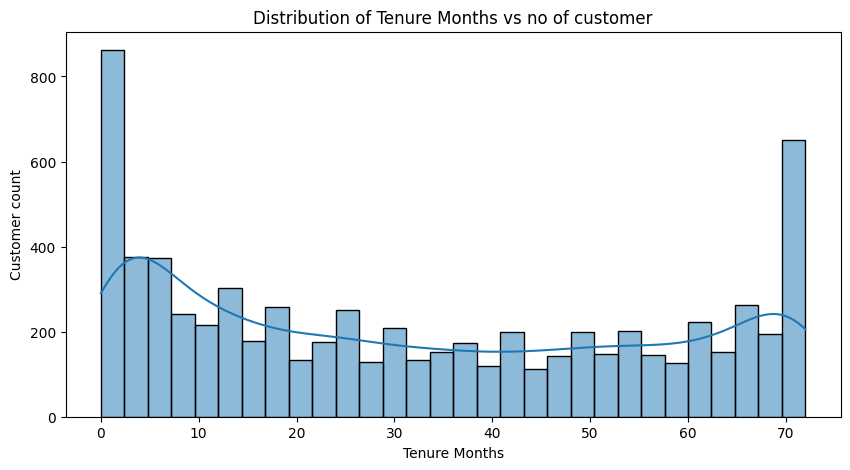

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Tenure Months'],bins=30,kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

In [ ]:
df['Tenure Months'].max(),df['Tenure Months'].min()

(72, 0)

In [ ]:
(72-0)/30

2.4

<Axes: xlabel='Tenure Months', ylabel='Count'>

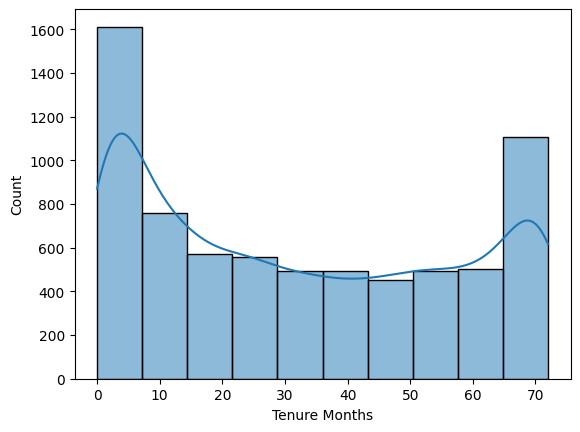

In [ ]:
sns.histplot(df['Tenure Months'],bins=10,kde=True)

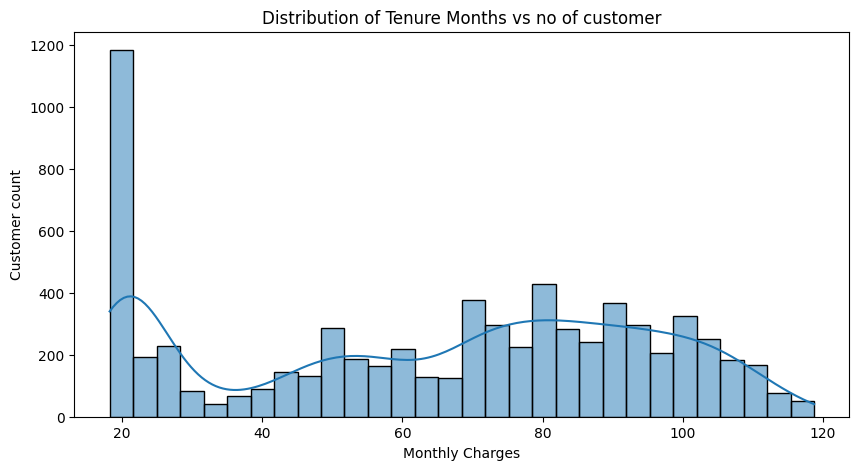

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Monthly Charges'],bins=30,kde=True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer count')
plt.title('Distribution of Monthly Charges')
plt.show()

In [ ]:
df['Monthly Charges'].max(),df['Monthly Charges'].min()

(118.75, 18.25)

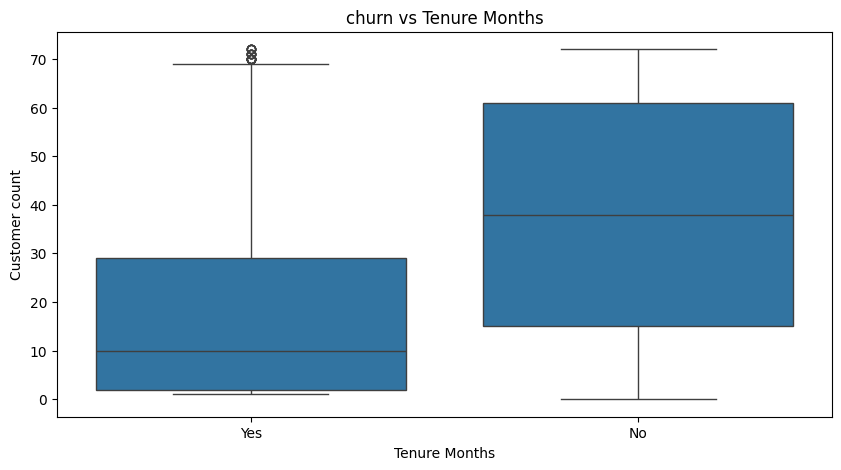

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(y='Tenure Months',x='Churn Label',data=df)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('churn vs Tenure Months')
plt.show()

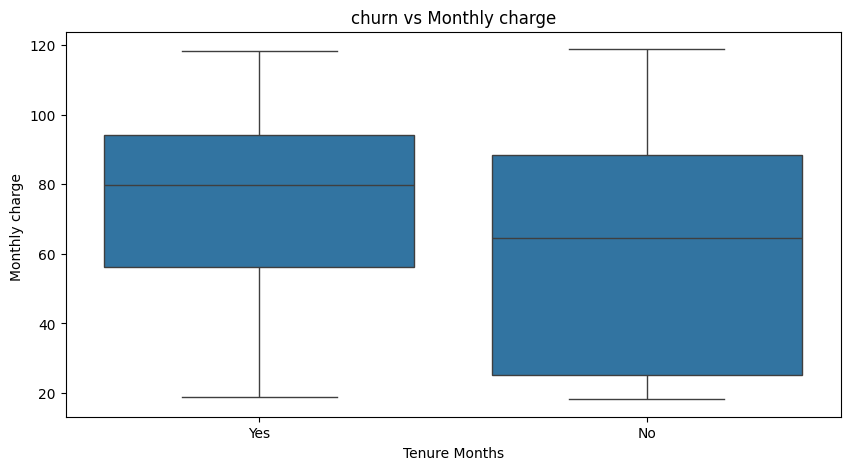

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(y='Monthly Charges',x='Churn Label',data=df)
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('churn vs Monthly charge')
plt.show()

In [ ]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [ ]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [ ]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


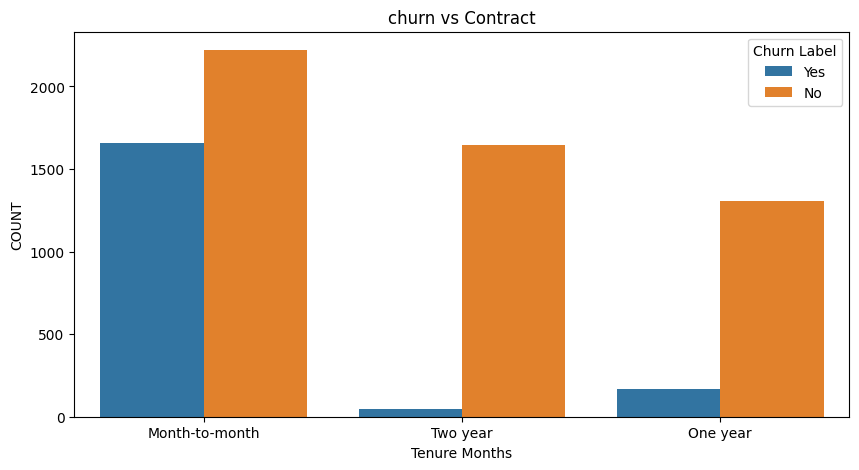

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Contract',hue='Churn Label',data=df)
plt.xlabel('Tenure Months')
plt.ylabel('COUNT')
plt.title('churn vs Contract')
plt.show()


In [ ]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

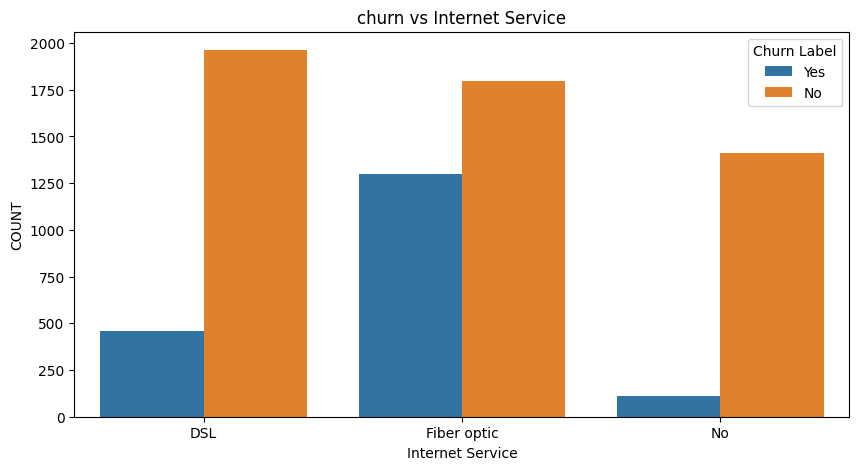

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Internet Service',hue='Churn Label',data=df)
plt.xlabel('Internet Service')
plt.ylabel('COUNT')
plt.title('churn vs Internet Service')
plt.show()


In [ ]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

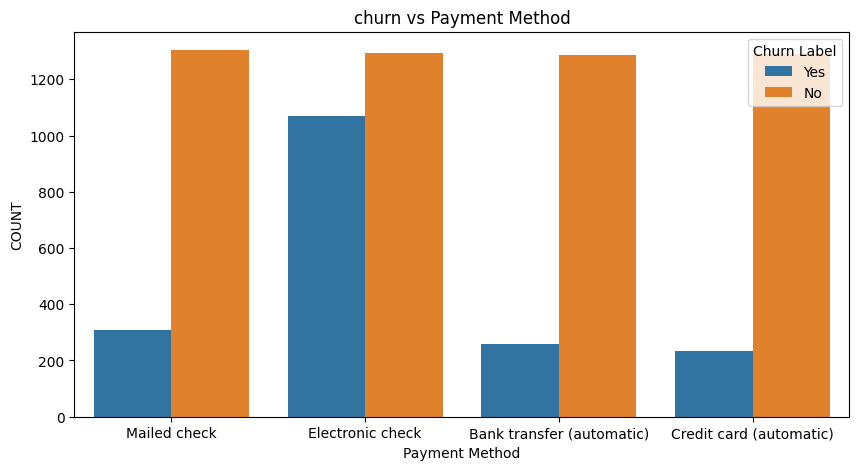

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Payment Method',hue='Churn Label',data=df)
plt.xlabel('Payment Method')
plt.ylabel('COUNT')
plt.title('churn vs Payment Method')
plt.show()


In [ ]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

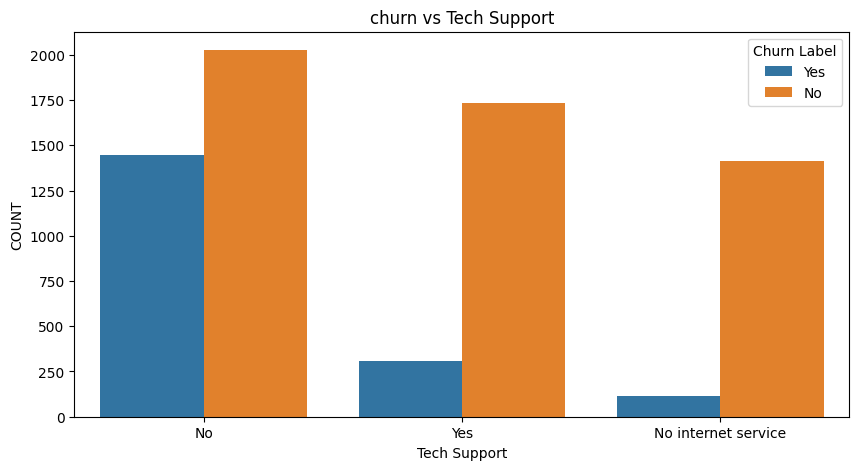

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Tech Support',hue='Churn Label',data=df)
plt.xlabel('Tech Support')
plt.ylabel('COUNT')
plt.title('churn vs Tech Support')
plt.show()

In [ ]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
num_col=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']

In [ ]:
corr_mt=df[num_col].corr()
corr_mt

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


<Axes: >

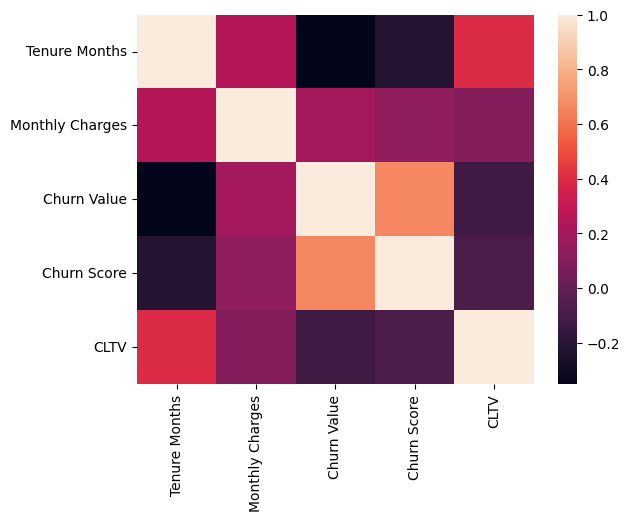

In [ ]:

sns.heatmap(corr_mt)

In [ ]:
Contract_churn =pd.crosstab(df['Contract'],df['Churn Label'])
Contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [ ]:
Contract_churn =pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
Contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [ ]:
tech_support_churn =pd.crosstab(df['Tech Support'],df['Churn Label'])
tech_support_churn

Churn Label,No,Yes
Tech Support,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


# data cleaning

In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
df['Total Charges'].unique()

array([108.15, 151.65, 820.5, ..., 7362.9, 346.45, 6844.5], dtype=object)

In [ ]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [ ]:
df[df['Tenure Months']==0]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [ ]:
[7043-7032,(11/7043)]

[11, 0.001561834445548772]

In [ ]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label',
              'Churn Score','CLTV','Churn Reason']

df=df.drop(columns=drop_columns)

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [ ]:
df['City'].unique()

array(['Los Angeles', 'Beverly Hills', 'Huntington Park', ..., 'Standish',
       'Tulelake', 'Olympic Valley'], dtype=object)

In [ ]:
df=df.drop(columns='City')

In [ ]:
df_encode=pd.get_dummies(df,drop_first=True)

In [ ]:
df_encode.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
df_encode.columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

In [ ]:
X=df_encode.drop(columns='Churn Value')
# drop('churn Value,axis=1)
y=df_encode['Churn Value']

In [ ]:
X.shape,y.shape

((7043, 30), (7043,))

In [ ]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [ ]:
# X.info()
(5174/7043)*100,(1869/7043)*100


(73.4630129206304, 26.536987079369588)

## 📊 Business Insights from EDA

> Key findings before building the model:

| Observation | Finding |
|---|---|
| 🔴 Month-to-month contracts | Highest churn rate (~45%) |
| 🟢 Two-year contracts | Lowest churn rate (~3%) |
| 💰 High monthly charges | Churners pay significantly more on average |
| ⏳ Tenure | Churned customers leave early (low median tenure) |
| 📶 Fiber Optic users | More likely to churn than DSL users |
| 🛠️ No Tech Support | Strongly associated with churning |

**Strategy Recommendation:** Target month-to-month, high-charge, low-tenure customers for retention campaigns.

# machine learning implementation

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [ ]:
X_train.shape,X_test.shape ,y_train.shape,y_test.shape

((5634, 30), (1409, 30), (5634,), (1409,))

In [ ]:
!pip install CHAID


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,precision_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
#ML MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier ,GradientBoostingClassifier,VotingClassifier
from xgboost import XGBClassifier
from CHAID import Tree

In [ ]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.7856635911994322

In [ ]:
confusion_matrix(y_test,y_pred)

array([[902, 107],
       [195, 205]])

In [ ]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [ ]:
# df['Churn Value'].value_counts()

# Approach handeling imbalance data

In [ ]:
balance_model=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
balance_model.fit(X_train,y_train)
y_pred=balance_model.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.7920511000709723

In [ ]:
confusion_matrix(y_test,y_pred)

array([[907, 102],
       [191, 209]])

In [ ]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



#hyper parameter Tuning

In [ ]:
hp_balance_model2=RandomForestClassifier(n_estimators=300,random_state=42,max_depth=10,class_weight='balanced')
hp_balance_model2.fit(X_train,y_train)
y_pred=hp_balance_model2.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)


0.7828246983676366

In [ ]:
confusion_matrix(y_test,y_pred)

array([[804, 205],
       [101, 299]])

In [ ]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [ ]:
hp_balance_model=RandomForestClassifier(n_estimators=100,
                                        max_depth=3,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model.fit(X_train,y_train)
y_pred=hp_balance_model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.730305180979418
[[704 305]
 [ 75 325]]
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1009
           1       0.52      0.81      0.63       400

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.79      0.73      0.74      1409



In [ ]:
hp_balance_model=RandomForestClassifier(n_estimators=800,
                                        max_depth=131,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model.fit(X_train,y_train)
y_pred=hp_balance_model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7877927608232789
[[907 102]
 [197 203]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.67      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



## approach feature importance analysis

<Axes: xlabel='Importance', ylabel='Features'>

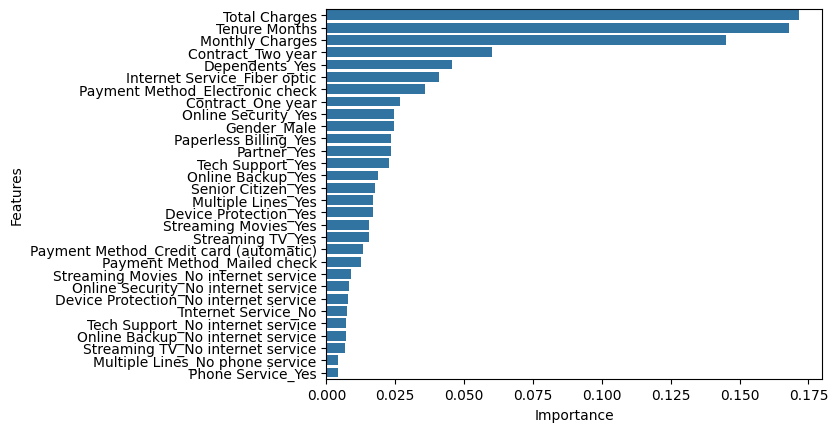

In [ ]:
# import panda as pd
fi=pd.DataFrame({
    'Features':X.columns,
    'Importance':hp_balance_model.feature_importances_
})
fi=fi.sort_values('Importance',ascending=False)
# fi

sns.barplot(y=fi['Features'],x=fi['Importance'])
# plt.xticks(rotation=90)

In [ ]:
fi.tail(10)

,Features,Importance
29,Payment Method_Mailed check,0.012423
22,Streaming Movies_No internet service,0.008770
12,Online Security_No internet service,0.008113
16,Device Protection_No internet service,0.007753
11,Internet Service_No,0.007324
18,Tech Support_No internet service,0.007014
14,Online Backup_No internet service,0.006989
20,Streaming TV_No internet service,0.006909
8,Multiple Lines_No phone service,0.004193
7,Phone Service_Yes,0.004089


In [ ]:
x_select=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [ ]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    x_select, y, test_size=0.20, random_state=42)


In [ ]:
hp_balance_model3=RandomForestClassifier(n_estimators=300,
                                        max_depth=10,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model3.fit(X_train_sel,y_train_sel)
y_pred=hp_balance_model3.predict(X_test_sel)
print(accuracy_score(y_test_sel,y_pred))
print(confusion_matrix(y_test_sel,y_pred))
print(classification_report(y_test_sel,y_pred))

0.7835344215755855
[[807 202]
 [103 297]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [ ]:
# ── ROC-AUC Curve ─────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

y_prob_roc = hp_balance_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_roc)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='#aaaaaa', linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
print(f"🎯 AUC Score: {roc_auc:.4f}")

In [ ]:
# ── Churn Probability Distribution ────────────────────────────────────────────
y_prob2 = hp_balance_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 5))
plt.hist(y_prob2[y_test == 0], bins=40, alpha=0.65, color='#2ecc71', label='Actual: No Churn', edgecolor='white')
plt.hist(y_prob2[y_test == 1], bins=40, alpha=0.65, color='#e74c3c', label='Actual: Churn', edgecolor='white')
plt.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision Threshold (0.5)')
plt.xlabel('Predicted Churn Probability')
plt.ylabel('Number of Customers')
plt.title('Churn Probability Distribution by Actual Class')
plt.legend()
plt.tight_layout()
plt.show()

## Customer Segmentation

In [ ]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

In [ ]:
df.shape


(7043, 20)

In [ ]:
segmentation_data=pd.DataFrame({
    'Tenure Months':df['Tenure Months'],
    'Monthly Charges':df['Monthly Charges'],
    'Total Charges':df['Total Charges'],
    'Churn probablity':y_prob2
})


In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn probablity
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


In [ ]:
scaler=StandardScaler()
segmentation_data_scaled=scaler.fit_transform(segmentation_data)

In [ ]:
std=pd.DataFrame(segmentation_data_scaled)
std

,0,1,2,3
0,-1.236724,-0.362660,-0.958066,1.024868
1,-1.236724,0.197365,-0.938874,1.413854
2,-0.992402,1.159546,-0.643789,1.445918
3,-0.177995,1.330711,0.338085,0.652607
4,0.677133,1.294151,1.216150,0.503752
...,...,...,...,...
7038,1.613701,-1.449476,-0.379565,-1.175321
7039,-0.340876,0.665992,-0.127605,-0.918804
7040,1.613701,1.277533,2.242606,-1.026938
7041,-0.870241,-1.168632,-0.852932,-0.199087


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

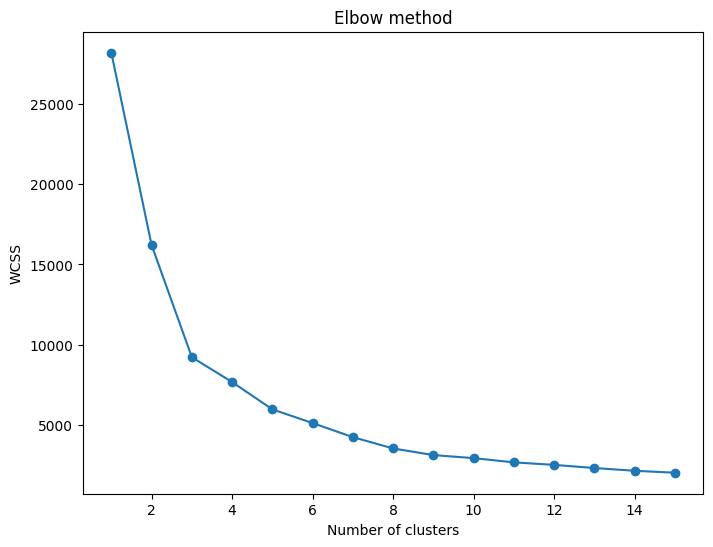

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(segmentation_data_scaled)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow method')
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(segmentation_data_scaled)
cluster=kmeans.fit_predict(segmentation_data)

In [ ]:
segmentation_data['cluster']=cluster

In [ ]:
segmentation_data.sample(5)

,Tenure Months,Monthly Charges,Total Charges,Churn probablity,cluster
6477,25,54.20,1423.15,0.135821,2
2825,62,84.50,5193.20,0.022715,1
1480,29,80.15,2265.25,0.639230,0
2262,56,99.90,5706.30,0.189859,1
6398,60,20.95,1270.55,0.000708,2


In [ ]:
cluster_summary=segmentation_data.groupby('cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn probablity
cluster,,,,
0,44.106634,77.689895,3272.602139,0.328949
1,64.373312,97.922399,6292.972558,0.219693
2,18.173100,49.752697,684.394390,0.419929


In [ ]:
cluster_summary={
    0:'Budget Loyal Customer',
    1:'High risk new Customer',
    2:'Loyal premium Customer'
}

In [ ]:
segmentation_data['quality']=segmentation_data['cluster'].map(cluster_summary)
segmentation_data.sample(5)

,Tenure Months,Monthly Charges,Total Charges,Churn probablity,cluster,quality
2739,13,80.00,1029.35,0.560949,2,Loyal premium Customer
6835,70,79.40,5528.90,0.133712,1,High risk new Customer
418,2,74.70,165.40,0.872918,2,Loyal premium Customer
3382,71,90.35,6325.25,0.013471,1,High risk new Customer
2909,64,100.30,6603.80,0.276107,1,High risk new Customer


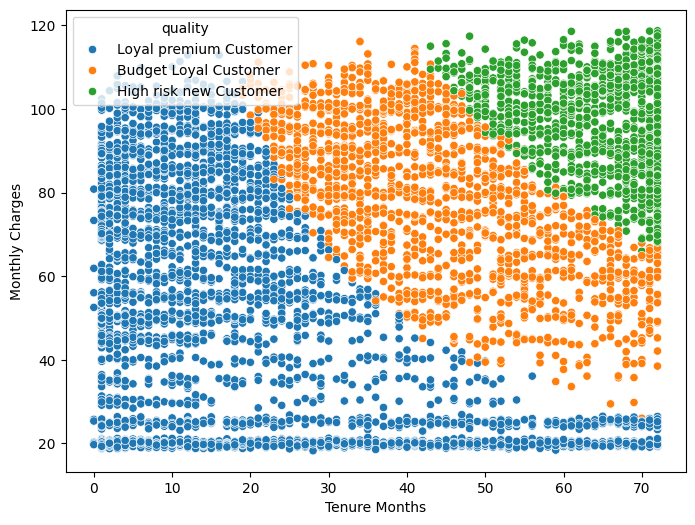

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months',y='Monthly Charges',data=segmentation_data,hue='quality')
plt.show()
#

## ✅ Project Summary

### Model Performance
| Metric | Value |
|---|---|
| Model Used | Random Forest (class_weight='balanced') |
| Handling Imbalance | Class Weight Balancing |
| Key Features | Monthly Charges, Tenure, Contract Type |

### Customer Segments Identified
| Segment | Description |
|---|---|
| 🟡 Budget Loyal Customer | Long tenure, low charges, low churn risk |
| 🔴 High Risk New Customer | Short tenure, high churn probability |
| 🟢 Loyal Premium Customer | High charges but committed, low churn |

### Conclusion
This project analyzed Telco customer churn using EDA, machine learning classification, and unsupervised clustering. The model can help the business identify **high-risk customers early** and deploy targeted retention strategies.